In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchinfo import summary

sys.path.insert(0, "../")
from src.config import CLASS_NAMES, MOTOR_CHANNELS
from src.networks import EEGNet

In [2]:
print(f"Labels: {CLASS_NAMES}")
print(f"Channels: {MOTOR_CHANNELS}")

Labels: ('elbow_flex_ext', 'hand_open_close', 'forearm_sup_pron', 'rest')
Channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6']


In [3]:
train_dataset = "../data/processed/dataset_train.npz"
test_dataset = "../data/processed/dataset_test.npz"

## **Load data**

In [4]:
def load_npz_split(path) -> tuple[np.ndarray, np.ndarray, dict]:
    z = np.load(path, allow_pickle=True)
    X = np.asarray(z["X"], dtype=np.float64)
    y = np.asarray(z["y"]).astype(np.int64).ravel()
    meta = {
        "sfreq": float(np.asarray(z["sfreq"]).squeeze()),
        "ch_names": [str(x) for x in np.asarray(z["ch_names"], dtype=object).ravel()],
        "split": str(np.asarray(z["split"]).ravel()[0]),
        "path": path,
    }
    return X, y, meta

X_train, y_train, train_meta = load_npz_split(train_dataset)
X_test, y_test, test_meta = load_npz_split(test_dataset)

In [5]:
print(X_train.shape, y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {int(c):d} {CLASS_NAMES[int(c)]}: {int(n)} trials")

(4876, 21, 257) (4876,)
  0 elbow_flex_ext: 1479 trials
  1 hand_open_close: 1314 trials
  2 forearm_sup_pron: 1335 trials
  3 rest: 748 trials


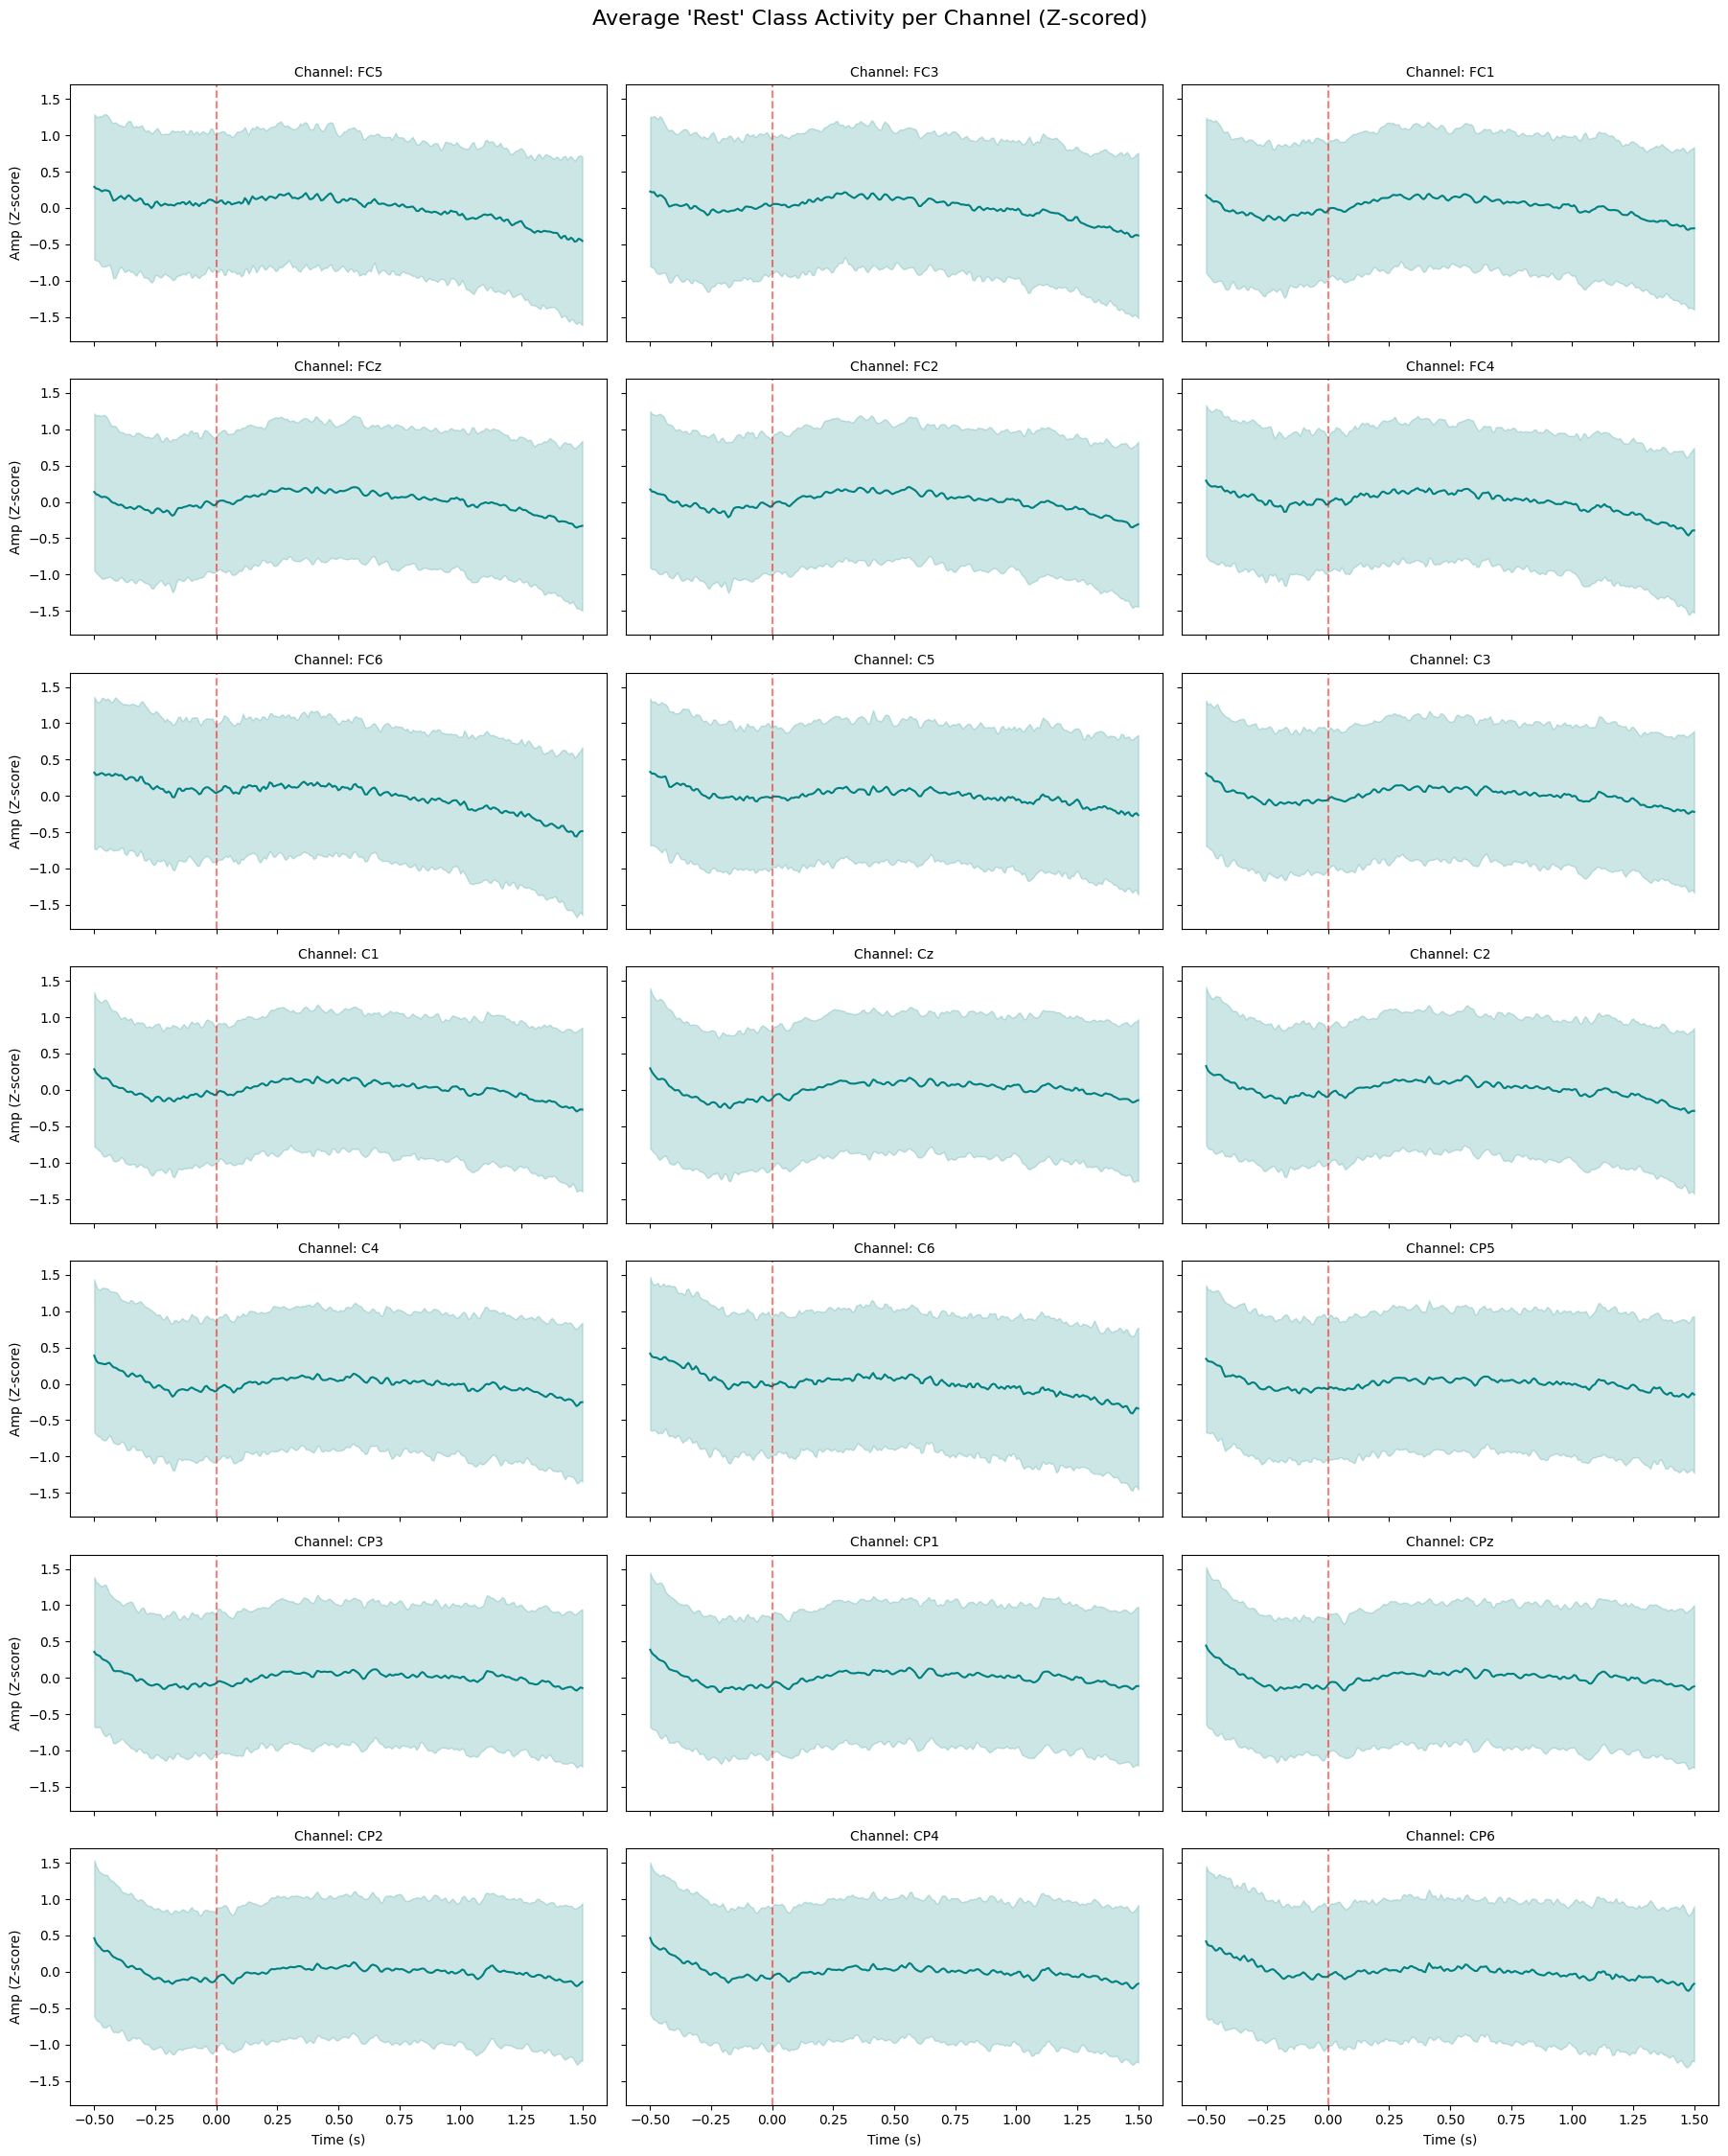

In [6]:
def plot_rest_class_averages(X, y, label, ch_names, sfreq=128.0):
    """
    Plots the average and +/- std shadow for the 'rest' class across all channels.
    
    Parameters:
    X : np.ndarray, shape (n_epochs, n_channels, n_times)
    y : np.ndarray, shape (n_epochs,)
    ch_names : list of str
    sfreq : float, sampling frequency
    """
    rest_idx = np.where(y == label)[0]
    X_rest = X[rest_idx]
    
    # Calculate Mean and STD across epochs (axis 0)
    mean_rest = np.mean(X_rest, axis=0) # (21, 321)
    std_rest = np.std(X_rest, axis=0)   # (21, 321)
    t = np.linspace(-0.5, 1.5, X.shape[2])
    
    fig, axes = plt.subplots(7, 3, figsize=(18, 22), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i in range(len(ch_names)):
        ax = axes[i]
        ax.plot(t, mean_rest[i], color='teal', lw=1.5, label='Mean Rest')
        ax.fill_between(t, 
                        mean_rest[i] - std_rest[i], 
                        mean_rest[i] + std_rest[i], 
                        color='teal', alpha=0.2, label='±1 STD')
        ax.set_title(f"Channel: {ch_names[i]}", fontsize=10)
        ax.axvline(0, color='red', linestyle='--', alpha=0.5) # Cue onset
        
        if i >= 18: # Bottom row
            ax.set_xlabel('Time (s)')
        if i % 3 == 0: # Left column
            ax.set_ylabel('Amp (Z-score)')

    plt.tight_layout()
    plt.suptitle("Average 'Rest' Class Activity per Channel (Z-scored)", fontsize=16, y=1.02)
    plt.savefig("rest_class_averages.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_rest_class_averages(X_train, y_train, 3, MOTOR_CHANNELS)

### *PLot Event Grand Average*

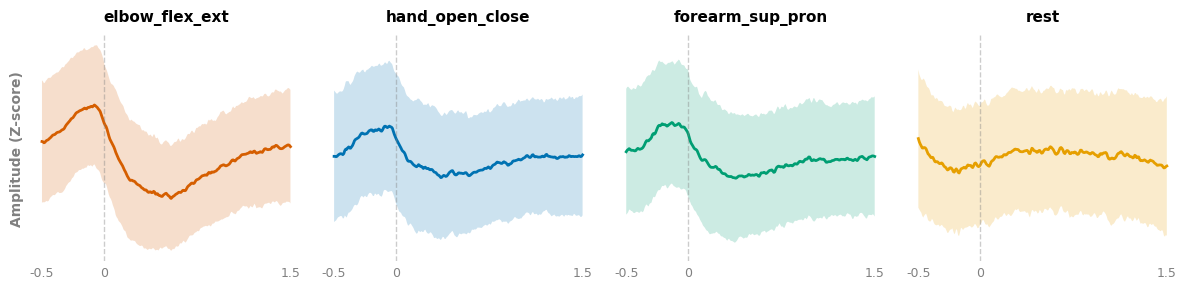

In [7]:
plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

t = np.linspace(-0.5, 1.5, X_train.shape[2])

fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True, sharey=True)

selected_channel = "Cz"
channel_idx = MOTOR_CHANNELS.index(selected_channel)

colors = ['#D55E00', '#0072B2', '#009E73', '#E69F00']

for idx, name in enumerate(CLASS_NAMES):
    ax = axes[idx]
    
    events = X_train[y_train == idx]
    mean_val = np.mean(events, axis=0)[channel_idx]
    std_val = np.std(events, axis=0)[channel_idx]
    
    # Plot target mean and STD
    ax.plot(t, mean_val, color=colors[idx], lw=2)
    ax.fill_between(t, 
                    mean_val - std_val, 
                    mean_val + std_val, 
                    color=colors[idx], alpha=0.2, edgecolor='none')
    
    # Add the vertical line at t=0
    ax.axvline(0, color='gray', linestyle='--', alpha=0.4, lw=1)
    
    ax.set_title(name, fontsize=11, fontweight='bold', pad=10)

    for spine in ax.spines.values():
        spine.set_visible(False)
        
    end_t = 1.5
    ax.set_xticks([-0.5, 0, end_t])
    ax.set_xticklabels(['-0.5', '0', str(end_t)], color='gray', fontsize=9)
    ax.tick_params(axis='both', which='both', length=0)
    
    if idx == 0:
        ax.set_ylabel("Amplitude (Z-score)", fontweight='bold', color='gray')
        ax.tick_params(axis='y', labelcolor='gray', labelsize=9)
    else:
        # Hide y-ticks completely for the other 3 plots
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("../report/img/filtered_eeg_grand_average.svg", format="svg", bbox_inches='tight', transparent=True)
plt.show()

### **Visualizing input tensor**

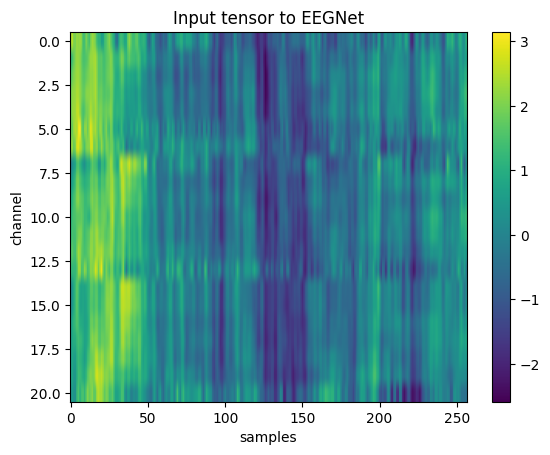

In [8]:
plt.figure()
plt.imshow(X_train[0],  aspect='auto')
plt.title("Input tensor to EEGNet")
plt.xlabel("samples")
plt.ylabel("channel")
plt.colorbar()
plt.show()

## **Build Model**

In this case we are going to build a deep learning model that will learn the temporal dynamics of the different channels for each event type.

In [9]:
n_channels=21 
n_classes=4 
sfreq=128
F1=8
D=4
F2=16
dropout_rate=0.5

net = EEGNet(
    n_channels, n_classes, sfreq, F1, D, F2, dropout_rate
)
summary(net, input_size=(1, 1, 21, 321))

Layer (type:depth-idx)                   Output Shape              Param #
EEGNet                                   [1, 4]                    --
├─Sequential: 1-1                        [1, 8, 21, 322]           --
│    └─Conv2d: 2-1                       [1, 8, 21, 322]           512
│    └─BatchNorm2d: 2-2                  [1, 8, 21, 322]           16
├─Sequential: 1-2                        [1, 32, 1, 80]            --
│    └─Conv2d: 2-3                       [1, 32, 1, 322]           672
│    └─BatchNorm2d: 2-4                  [1, 32, 1, 322]           64
│    └─ELU: 2-5                          [1, 32, 1, 322]           --
│    └─AvgPool2d: 2-6                    [1, 32, 1, 80]            --
│    └─Dropout: 2-7                      [1, 32, 1, 80]            --
├─Sequential: 1-3                        [1, 16, 1, 10]            --
│    └─Conv2d: 2-8                       [1, 32, 1, 81]            512
│    └─Conv2d: 2-9                       [1, 16, 1, 81]            512
│    └─Batc

## **Train model**

### *Build Dataset*

In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tensor = torch.from_numpy(X_train).float()
y_tensor = torch.from_numpy(y_train).long()

# Add the 1-depth dimension for the Conv2d layer: (Batch, 1, 21, 321)
X_tensor = X_tensor.unsqueeze(1)

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

# Add the 1-depth dimension for the Conv2d layer: (Batch, 1, 21, 321)
X_test_tensor = X_test_tensor.unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create DataLoader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [14]:
X_train.shape

(4876, 21, 257)

### *Training Loop*

In [11]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = net.to(device)

counts = torch.tensor([766, 602, 621, 396], dtype=torch.float)
weights = 1.0 / counts
weights = weights / weights.sum() # Normalize
weights = weights.to(device)

num_epochs = 100
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # tqdm creates the progress bar
    pbar = tqdm(enumerate(loader), total=len(loader), desc="Training", leave=False)
    
    for batch_idx, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update the progress bar text
        pbar.set_postfix({
            'loss': f'{running_loss/(batch_idx+1):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
        
    return running_loss / len(loader), 100. * correct / total

# Storage for plotting
history = {
    'train_loss': [], 
    'train_acc': [], 
    'val_loss': [], 
    'val_acc': []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for batch_raw, labels in test_loader:  # Use your test/validation loader
            batch_raw, labels = batch_raw.to(device),  labels.to(device)
            
            outputs = model(batch_raw)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100. * val_correct / val_total
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Update learning rate based on the validation loss to avoid overfitting/stalling
    scheduler.step(epoch_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | LR: {current_lr:.6f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x128 and 160x4)

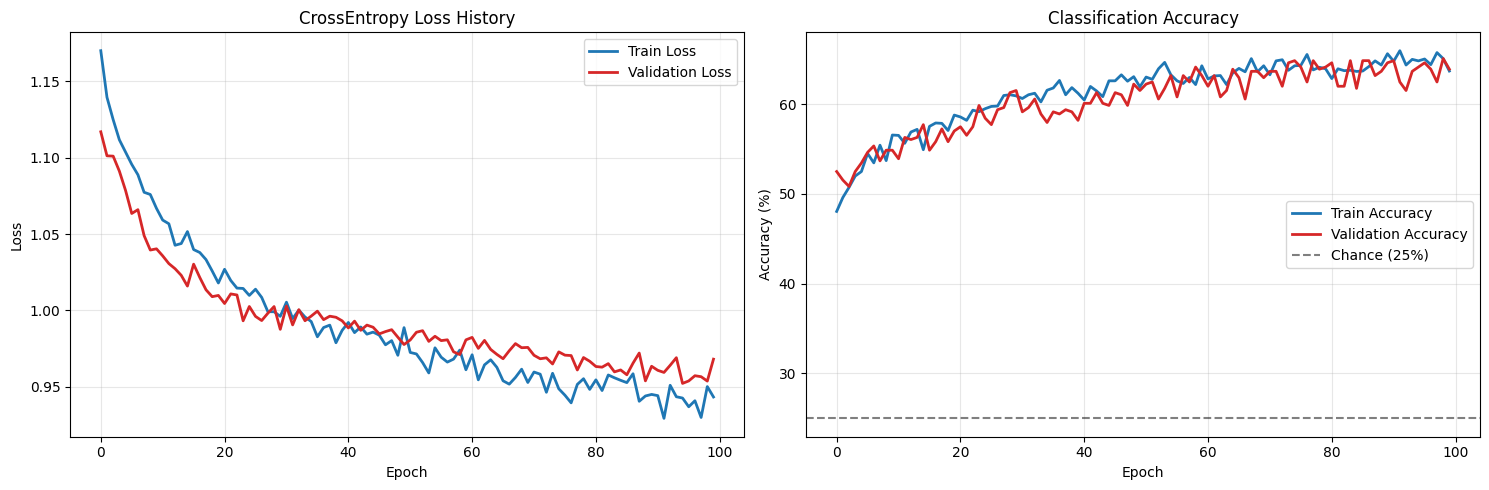

In [ ]:
from src.utils import plot_history

plot_history(history)

## **Evaluate the performance**

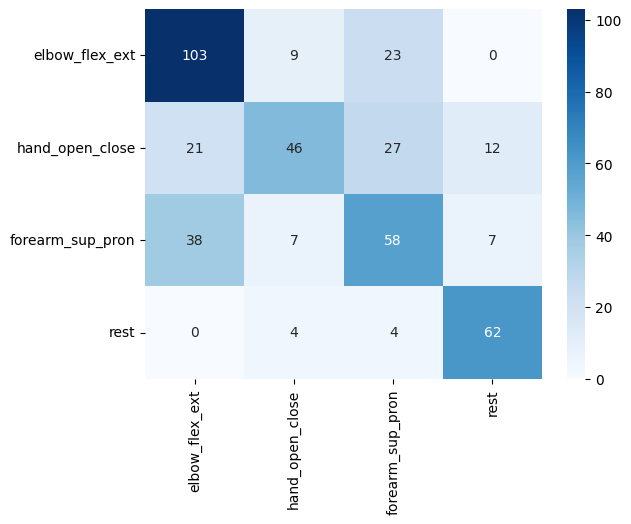

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.show()

    return cm, all_labels, all_preds

cm, labels, preds = plot_cm(model, test_loader, device)

In [ ]:
diff = np.array(preds) == np.array(labels)
correct = np.where(diff == True)[0]
test_accuracy = len(correct) / len(preds)
print(f"Test Accuracy for the model is: {test_accuracy}")

Test Accuracy for the model is: 0.6389548693586699


## View Model Insights before Classification

Extracting bottleneck features from test set...
Running t-SNE (this may take a minute)...


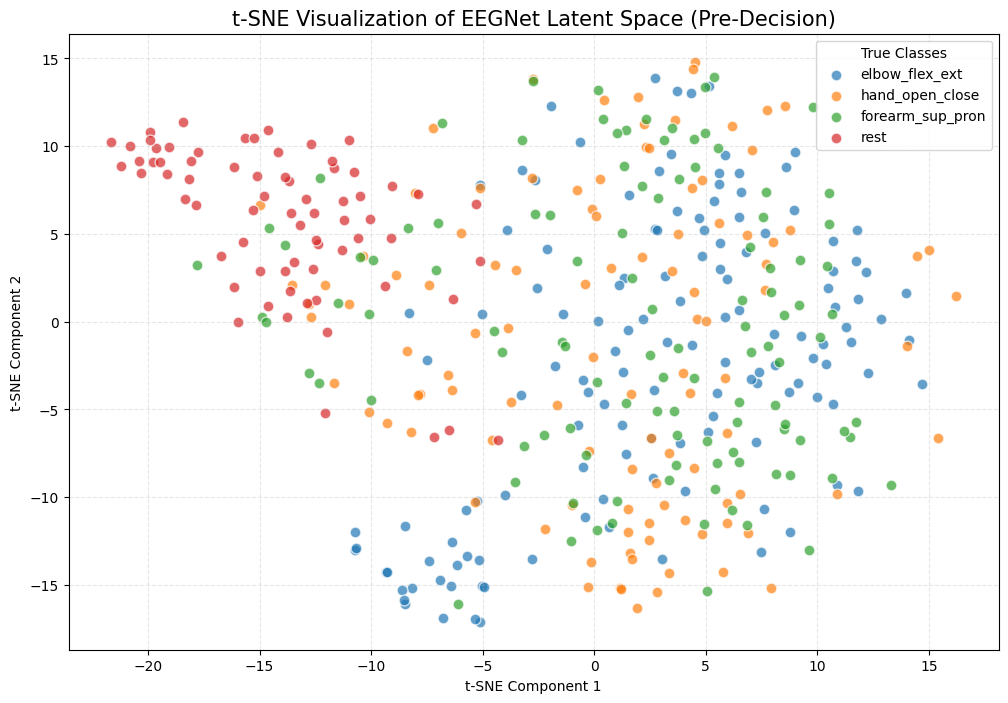

In [ ]:
from sklearn.manifold import TSNE

def get_bottleneck_features(model, loader, device):
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            
            # Step-by-step forward pass to stop before the Linear layer
            x = model.temporal_conv(inputs)
            x = model.depthwise_conv(x)
            x = model.temporal_summary(x)
            x = torch.flatten(x, 1) # This is our feature vector (e.g., size 160)
            
            features.append(x.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(features), np.concatenate(labels_list)

def plot_feature_clusters(model, test_loader, device, class_names):
    # Extract features
    print("Extracting bottleneck features from test set...")
    features, labels = get_bottleneck_features(model, test_loader, device)
    
    # Apply t-SNE
    print("Running t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct professional colors
    
    for i, class_name in enumerate(class_names):
        indices = np.where(labels == i)
        plt.scatter(
            features_2d[indices, 0], 
            features_2d[indices, 1], 
            c=colors[i], 
            label=class_name,
            alpha=0.7, 
            edgecolors='w', 
            s=60
        )
    
    plt.title("t-SNE Visualization of EEGNet Latent Space (Pre-Decision)", fontsize=15)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="True Classes", loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()


plot_feature_clusters(net, test_loader, device, CLASS_NAMES)